# 🏠 Análisis Exploratorio del Dataset: Casas Usadas RM

**Objetivo:** Explorar los datos crudos de propiedades en la Región Metropolitana, identificar inconsistencias (valores nulos, tipos incorrectos, outliers) y definir un flujo de limpieza y transformación que luego aplicaremos mediante un Pipeline de scikit-learn.

**Diccionario de Variables Clave:**

- `Comuna`: Comuna de la Región Metropolitana donde se ubica la propiedad.
- `Tipo_Vivienda`: Tipo de propiedad (solo contiene 'Casa' en este dataset).
- `N_Habitaciones`: Número de dormitorios de la propiedad.
- `N_Baños`: Número de baños de la propiedad.
- `N_Estacionamientos`: Cantidad de estacionamientos ('No' indica 0).
- `Total_Superficie_M2`: Superficie total del terreno en metros cuadrados.
- `Superficie_Construida_M2`: Superficie construida en metros cuadrados.
- `Valor_UF`: Precio de venta en Unidades de Fomento (UF).
- `Valor_CLP`: Precio de venta en pesos chilenos (CLP).
- `precio_sobre_mediana`: **Variable Objetivo.** ¿El precio supera la mediana del mercado? (1 = Sí, 0 = No).

## 0. Configuración del entorno

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para que los gráficos se vean profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga del Dataset

In [64]:
# Cargamos el dataset
df = pd.read_excel('../data/raw/Casas_usadas_-_RM_Mayo_2020.xlsx', sheet_name='RM Mayo 2020')
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (1139, 13)


,Comuna,Link,Tipo_Vivienda,N_Habitaciones,N_Baños,N_Estacionamientos,Total_Superficie_M2,Superficie_Construida_M2,Valor_UF,Valor_CLP,Dirección,Quién_Vende,Corredor
0,Calera de Tango,https://chilepropiedades.cl/ver-publicacion/ve...,Casa,5.00,6.00,3,"5,000.00",440,"12,200.00",351360000,"Calera de Tango, Queilen",Gabriela Mellado V.,Zenpro Propiedades
1,Calera de Tango,https://chilepropiedades.cl/ver-publicacion/ve...,Casa,6.00,6.00,6,"5,000.00",430,"13,000.00",374400000,"Calera de Tango, Queilen",Gabriela Mellado V.,Zenpro Propiedades
2,Calera de Tango,https://chilepropiedades.cl/ver-publicacion/ve...,Casa,3.00,3.00,No,"2,027.00",140,"10,300.00",296640000,"Calera de Tango, Avenida calera de tango con...",Alonso Baeza Rivera y Cía. Ltda. (Kennedy),Alonso Baeza Rivera y Cía. Ltda. (Kennedy)
3,Calera de Tango,https://chilepropiedades.cl/ver-publicacion/ve...,Casa,8.00,6.00,No,"5,000.00",480,"21,500.00",619200000,"Calera de Tango, Paradero 14 1/2/5 kilometros ...",RED Gestión Propiedades,Red Gestión Propiedades
4,Calera de Tango,https://chilepropiedades.cl/ver-publicacion/ve...,Casa,3.00,2.00,3,"5,000.00",196,"9,100.00",262080000,"Calera de Tango, Condominio El Trébol de Caler...",Gabriela Mellado V.,Zenpro Propiedades


## 2. Inspección Inicial — Estructura del Dataset

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Comuna                    1139 non-null   str    
 1   Link                      1139 non-null   str    
 2   Tipo_Vivienda             1139 non-null   str    
 3   N_Habitaciones            1131 non-null   float64
 4   N_Baños                   1118 non-null   float64
 5   N_Estacionamientos        1067 non-null   object 
 6   Total_Superficie_M2       1102 non-null   float64
 7   Superficie_Construida_M2  1103 non-null   object 
 8   Valor_UF                  1139 non-null   float64
 9   Valor_CLP                 1139 non-null   int64  
 10  Dirección                 1102 non-null   str    
 11  Quién_Vende               1139 non-null   str    
 12  Corredor                  1139 non-null   str    
dtypes: float64(4), int64(1), object(2), str(6)
memory usage: 115.8+ KB


In [66]:
#Contar los nulos por columna
df.isnull().sum()

Comuna                       0
Link                         0
Tipo_Vivienda                0
N_Habitaciones               8
N_Baños                     21
N_Estacionamientos          72
Total_Superficie_M2         37
Superficie_Construida_M2    36
Valor_UF                     0
Valor_CLP                    0
Dirección                   37
Quién_Vende                  0
Corredor                     0
dtype: int64

In [67]:
# Tipos de datos y valores nulos por columna de una mejor forma visualmente
print("=" * 55)
print(f"{'COLUMNA':<30} {'TIPO':<12} {'NULOS':>6}  {'%':>6}")
print("=" * 55)
for col in df.columns:
    nulos = df[col].isnull().sum()
    pct = 100 * nulos / len(df)
    print(f"{col:<30} {str(df[col].dtype):<12} {nulos:>6}  {pct:>5.1f}%")
print("=" * 55)

COLUMNA                        TIPO          NULOS       %
Comuna                         str               0    0.0%
Link                           str               0    0.0%
Tipo_Vivienda                  str               0    0.0%
N_Habitaciones                 float64           8    0.7%
N_Baños                        float64          21    1.8%
N_Estacionamientos             object           72    6.3%
Total_Superficie_M2            float64          37    3.2%
Superficie_Construida_M2       object           36    3.2%
Valor_UF                       float64           0    0.0%
Valor_CLP                      int64             0    0.0%
Dirección                      str              37    3.2%
Quién_Vende                    str               0    0.0%
Corredor                       str               0    0.0%


In [68]:
# Estadísticas descriptivas de columnas numéricas
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe().round(2)

,N_Habitaciones,N_Baños,Total_Superficie_M2,Valor_UF,Valor_CLP
count,"1,131.00","1,118.00","1,102.00","1,139.00","1,139.00"
mean,4.11,2.65,866.10,"10,218.02","294,286,952.42"
std,1.60,1.39,"1,845.36","9,652.73","277,998,405.37"
min,1.00,1.00,0.00,"1,215.19","35,000,000.00"
25%,3.00,2.00,180.00,"3,541.42","102,000,000.00"
50%,4.00,2.00,293.00,"6,700.00","192,960,000.00"
75%,5.00,3.00,563.75,"13,510.00","389,088,000.00"
max,19.00,12.00,"30,000.00","70,828.41","2,040,000,000.00"


## 3. El problema de los valores faltantes (NaN)

En nuestro dataset los valores nulos vienen como `NaN` (no como texto). A continuación identificamos cuántos hay y en qué columnas.

--- Conteo de nulos por columna ---
N_Estacionamientos          72
Total_Superficie_M2         37
Dirección                   37
Superficie_Construida_M2    36
N_Baños                     21
N_Habitaciones               8
dtype: int64


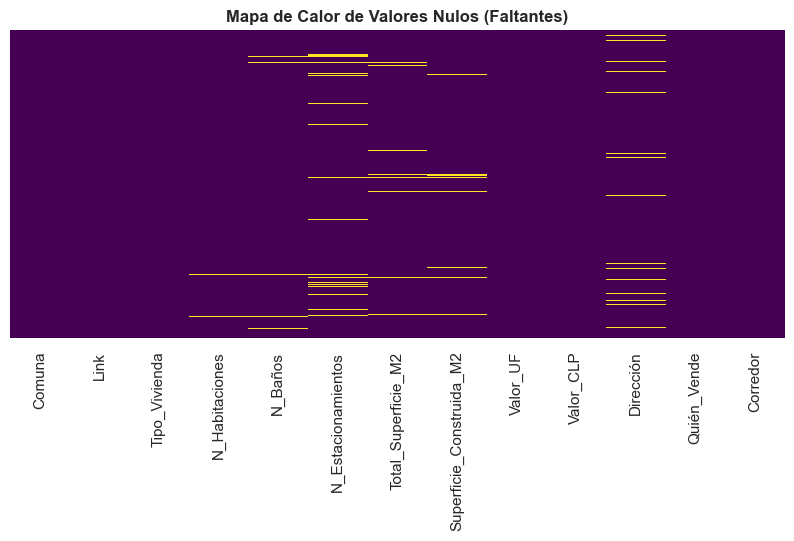

In [69]:
# Mapa de calor de valores nulos
#Pero con NaN reales en vez de 'unknown'
print("--- Conteo de nulos por columna ---")
conteo_nulos = df.isnull().sum()
print(conteo_nulos[conteo_nulos > 0].sort_values(ascending=False))

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Mapa de Calor de Valores Nulos (Faltantes)", fontweight='bold')
plt.show()

### 🔍 Hallazgos del EDA Inicial

| Problema detectado | Columna | Estrategia de solución |
|---|---|---|
| Tipo incorrecto (object en vez de numérico) | `N_Estacionamientos` | Reemplazar 'No'→0, convertir con `pd.to_numeric` |
| Tipo incorrecto (object en vez de numérico) | `Superficie_Construida_M2` | Convertir con `pd.to_numeric` |
| Valores nulos moderados (<10%) | `N_Habitaciones`, `N_Baños` | Imputación con mediana |
| Valores nulos moderados | `N_Estacionamientos`, `Total_Superficie_M2` | Imputación con mediana |
| Columnas irrelevantes | `Link`, `Tipo_Vivienda`, `Dirección` | Eliminación justificada |
| Columnas de alta cardinalidad | `Quién_Vende` (303 únicos), `Corredor` | Eliminación justificada |
| Outliers extremos | `Valor_UF` (max 70.828 vs mediana 6.700) | Winsorización IQR |


## 4. Análisis de la Variable Objetivo

In [70]:
# Definición de la variable objetivo
MEDIANA_UF = df['Valor_UF'].median()
print(f"Mediana del mercado : {MEDIANA_UF:,.2f} UF")
print(f"Media del mercado   : {df['Valor_UF'].mean():,.2f} UF")
print()

# Crear variable objetivo binaria
df['precio_sobre_mediana'] = (df['Valor_UF'] > MEDIANA_UF).astype(int)
conteo = df['precio_sobre_mediana'].value_counts()
print("Distribución de la variable objetivo:")
print(f"  0 (Bajo mediana) : {conteo[0]:>4} casas ({100*conteo[0]/len(df):.1f}%)")
print(f"  1 (Sobre mediana): {conteo[1]:>4} casas ({100*conteo[1]/len(df):.1f}%)")

Mediana del mercado : 6,700.00 UF
Media del mercado   : 10,218.02 UF

Distribución de la variable objetivo:
  0 (Bajo mediana) :  571 casas (50.1%)
  1 (Sobre mediana):  568 casas (49.9%)


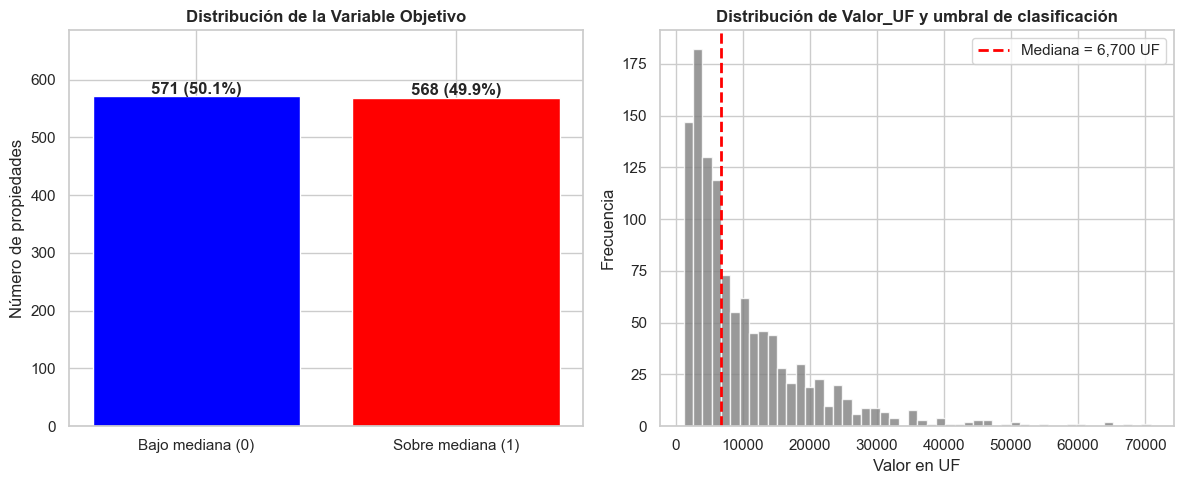

In [71]:
# Visualización de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Distribución binaria
valores = [conteo[0], conteo[1]]
labels = ['Bajo mediana (0)', 'Sobre mediana (1)']
axes[0].bar(labels, valores, color=['blue', 'red'])
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Número de propiedades')
for i, val in enumerate(valores):
    axes[0].text(i, val + 5, f'{val} ({100*val/len(df):.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(valores) * 1.2)

# Gráfico 2: Distribución de Valor_UF con línea de mediana
axes[1].hist(df['Valor_UF'], bins=50, color='gray', edgecolor='white', alpha=0.8)
axes[1].axvline(MEDIANA_UF, color='red', linewidth=2, linestyle='--',
                label=f'Mediana = {MEDIANA_UF:,.0f} UF')
axes[1].set_title('Distribución de Valor_UF y umbral de clasificación', fontweight='bold')
axes[1].set_xlabel('Valor en UF')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/01_variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis por Comuna

In [72]:
# Precio mediano por comuna
comunas_stats = df.groupby('Comuna').agg(
    precio_mediano_uf=('Valor_UF', 'median'),
    n_casas=('Valor_UF', 'count'),
    pct_sobre_mediana=('precio_sobre_mediana', 'mean')
).sort_values('precio_mediano_uf', ascending=False).head(15)

comunas_stats['pct_sobre_mediana'] = (comunas_stats['pct_sobre_mediana'] * 100).round(1)
print(comunas_stats.to_string())

                 precio_mediano_uf  n_casas  pct_sobre_mediana
Comuna                                                        
Lo Barnechea             27,690.00       49             100.00
Las Condes               24,750.00       50              94.00
Vitacura                 18,995.00       48             100.00
La Reina                 16,500.00       45              91.10
Colina                   14,900.00       45              82.20
Providencia              13,722.44       48              95.80
Calera de Tango          12,600.00       14              92.90
Ñuñoa                    11,283.94       49              91.80
Santiago                 10,068.75       47              78.70
Peñalolén                 9,500.00       48              75.00
San Miguel                8,689.98       38              73.70
La Florida                6,800.00       29              51.70
La Cisterna               6,596.76       25              40.00
Huechuraba                6,250.00       27            

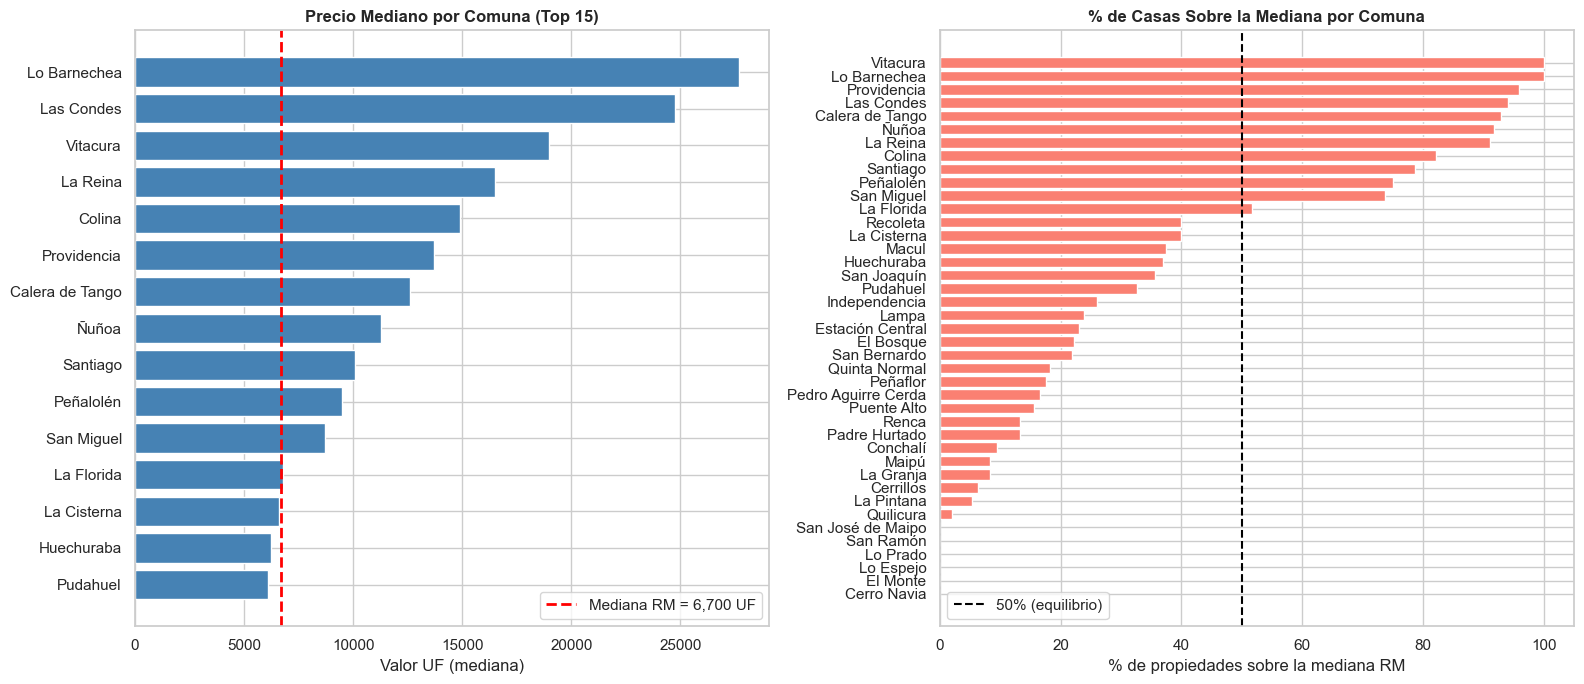

In [73]:
# Visualización por comuna
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Precio mediano por comuna (top 15)
all_comunas = df.groupby('Comuna')['Valor_UF'].median().sort_values(ascending=True)
top15 = all_comunas.tail(15)
axes[0].barh(top15.index, top15.values, color='steelblue', edgecolor='white')
axes[0].axvline(MEDIANA_UF, color='red', linewidth=2, linestyle='--',
                label=f'Mediana RM = {MEDIANA_UF:,.0f} UF')
axes[0].set_title('Precio Mediano por Comuna (Top 15)', fontweight='bold')
axes[0].set_xlabel('Valor UF (mediana)')
axes[0].legend()

# Gráfico 2: % sobre mediana por comuna
pct_sobre = df.groupby('Comuna')['precio_sobre_mediana'].mean().sort_values() * 100
axes[1].barh(pct_sobre.index, pct_sobre.values, color='salmon', edgecolor='white')
axes[1].axvline(50, color='black', linewidth=1.5, linestyle='--', label='50% (equilibrio)')
axes[1].set_title('% de Casas Sobre la Mediana por Comuna', fontweight='bold')
axes[1].set_xlabel('% de propiedades sobre la mediana RM')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/02_analisis_por_comuna.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análisis de Variables Numéricas

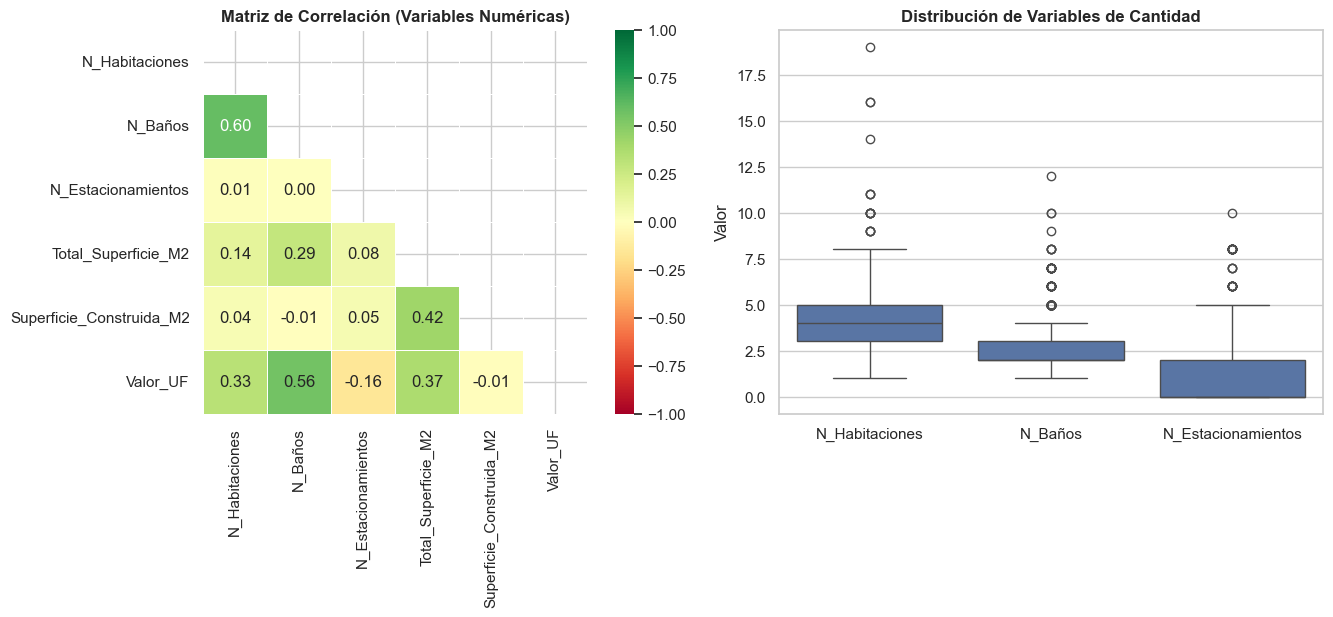

In [74]:
# Correlaciones entre variables numéricas
df_num = df.copy()
df_num['N_Estacionamientos'] = pd.to_numeric(
    df_num['N_Estacionamientos'].astype(str).replace('No', '0').replace('nan', np.nan),
    errors='coerce'
)
df_num['Superficie_Construida_M2'] = pd.to_numeric(df_num['Superficie_Construida_M2'], errors='coerce')

numericas = ['N_Habitaciones', 'N_Baños', 'N_Estacionamientos',
             'Total_Superficie_M2', 'Superficie_Construida_M2', 'Valor_UF']

corr_matrix = df_num[numericas].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de correlación
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=axes[0], vmin=-1, vmax=1, linewidths=0.5, square=True)
axes[0].set_title('Matriz de Correlación (Variables Numéricas)', fontweight='bold')

# Boxplot de variables de cantidad
df_box = df_num[['N_Habitaciones', 'N_Baños', 'N_Estacionamientos']].dropna()
df_melted = df_box.melt(var_name='Variable', value_name='Valor')
sns.boxplot(data=df_melted, x='Variable', y='Valor', ax=axes[1])
axes[1].set_title('Distribución de Variables de Cantidad', fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/03_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de Outliers en Valor_UF

In [75]:
# Análisis de outliers en Valor_UF con método IQR
Q1 = df['Valor_UF'].quantile(0.25)
Q3 = df['Valor_UF'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df[(df['Valor_UF'] < limite_inf) | (df['Valor_UF'] > limite_sup)]
print(f"Q1 = {Q1:,.1f} UF")
print(f"Q3 = {Q3:,.1f} UF")
print(f"IQR = {IQR:,.1f}")
print(f"Límite inferior = {limite_inf:,.1f} UF")
print(f"Límite superior = {limite_sup:,.1f} UF")
print(f"Outliers detectados = {len(outliers)} registros ({100*len(outliers)/len(df):.1f}%)")
print()
print("Estrategia: Winsorización (capping) — los valores extremos se recortan al límite,")
print("NO se eliminan, para preservar todos los registros del dataset.")

Q1 = 3,541.4 UF
Q3 = 13,510.0 UF
IQR = 9,968.6
Límite inferior = -11,411.4 UF
Límite superior = 28,462.9 UF
Outliers detectados = 62 registros (5.4%)

Estrategia: Winsorización (capping) — los valores extremos se recortan al límite,
NO se eliminan, para preservar todos los registros del dataset.


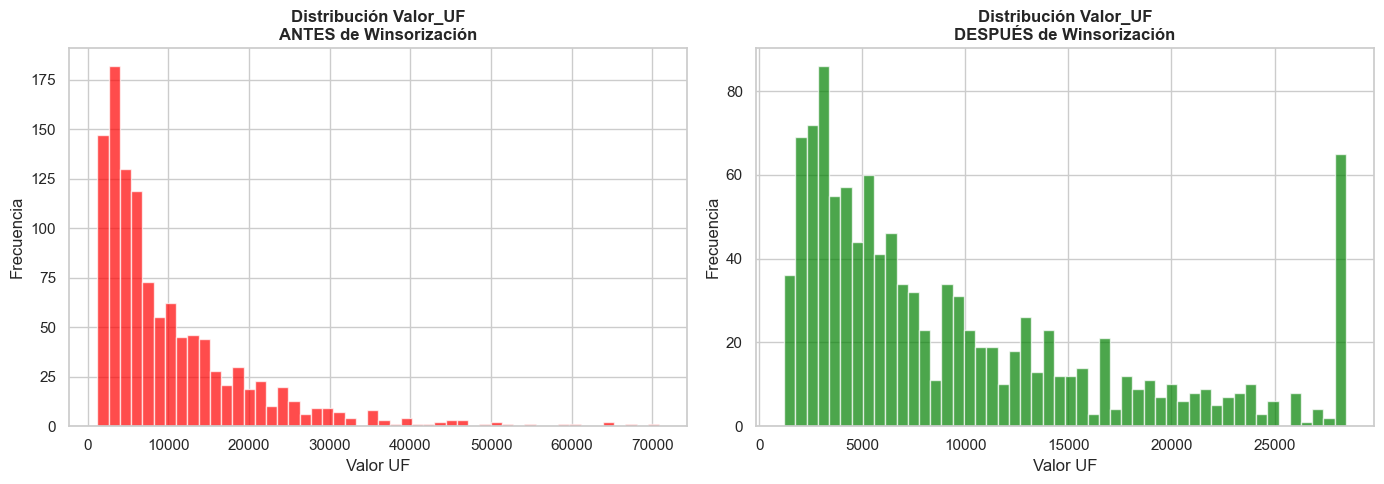

In [76]:
# Visualización antes/después de Winsorización
df_capped = np.clip(df['Valor_UF'], limite_inf, limite_sup)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Valor_UF'], bins=50, color='red', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribución Valor_UF\nANTES de Winsorización', fontweight='bold')
axes[0].set_xlabel('Valor UF')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_capped, bins=50, color='green', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribución Valor_UF\nDESPUÉS de Winsorización', fontweight='bold')
axes[1].set_xlabel('Valor UF')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../outputs/04_outliers_winsorizacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis del Problema de Tipo en N_Estacionamientos

In [77]:
# Problema de tipo en N_Estacionamientos
print("Valores únicos ANTES de limpiar:")
print(df['N_Estacionamientos'].value_counts().to_string())
print()
print(f"Tipo original: {df['N_Estacionamientos'].dtype}")
print()
print("Problema: 600 registros tienen el string 'No' en lugar de 0.")

# Solución
parking_fixed = pd.to_numeric(
    df['N_Estacionamientos'].astype(str).replace('No', '0').replace('nan', np.nan),
    errors='coerce'
)
print("\nDistribución DESPUÉS de la corrección:")
print(parking_fixed.value_counts().sort_index().to_string())

Valores únicos ANTES de limpiar:
N_Estacionamientos
No    600
2     172
1     125
3      78
4      47
8      17
5      14
6      10
7       3
10      1

Tipo original: object

Problema: 600 registros tienen el string 'No' en lugar de 0.

Distribución DESPUÉS de la corrección:
N_Estacionamientos
0.00     600
1.00     125
2.00     172
3.00      78
4.00      47
5.00      14
6.00      10
7.00       3
8.00      17
10.00      1


## 9. Transformaciones Avanzadas — Pivot Table

In [78]:
# Pivot Table: precio mediano en UF por Comuna y N° de Habitaciones
# Técnica de reshape que permite ver la relación entre dos variables categóricas sacando los NaN y poniendolos como 0 para mejor visualización
pivot1 = df.pivot_table(
    values='Valor_UF',
    index='Comuna',
    columns='N_Habitaciones',
    aggfunc='median',
    fill_value=0
).round(0)

print("Precio mediano (UF) por Comuna y N° de Habitaciones:")
print(pivot1.to_string())

Precio mediano (UF) por Comuna y N° de Habitaciones:
N_Habitaciones          1.00      2.00      3.00      4.00      5.00      6.00      7.00      8.00      9.00      10.00     11.00     14.00     16.00    19.00
Comuna                                                                                                                                                        
Calera de Tango          0.00      0.00 10,075.00      0.00 14,450.00 16,650.00 15,000.00 21,500.00      0.00      0.00      0.00      0.00      0.00     0.00
Cerrillos                0.00  5,000.00  3,194.00  4,791.00  4,948.00      0.00      0.00      0.00  7,330.00      0.00      0.00      0.00      0.00     0.00
Cerro Navia              0.00  1,805.00      0.00  4,080.00      0.00      0.00      0.00      0.00      0.00      0.00      0.00      0.00      0.00     0.00
Colina                   0.00  1,441.00  5,555.00 14,995.00 15,850.00 18,500.00      0.00 16,500.00      0.00      0.00      0.00      0.00      0.00   

In [79]:
#Pivot para la  visualicon del grafico 
# Pivot Table: precio mediano en UF por Comuna y N° de Habitaciones
# Técnica de reshape que permite ver la relación entre dos variables categóricas
pivot = df.pivot_table(
    values='Valor_UF',
    index='Comuna',
    columns='N_Habitaciones',
    aggfunc='median'
).round(0)

print("Precio mediano (UF) por Comuna y N° de Habitaciones:")
print(pivot.to_string())

Precio mediano (UF) por Comuna y N° de Habitaciones:
N_Habitaciones          1.00      2.00      3.00      4.00      5.00      6.00      7.00      8.00      9.00      10.00     11.00     14.00     16.00    19.00
Comuna                                                                                                                                                        
Calera de Tango           NaN       NaN 10,075.00       NaN 14,450.00 16,650.00 15,000.00 21,500.00       NaN       NaN       NaN       NaN       NaN      NaN
Cerrillos                 NaN  5,000.00  3,194.00  4,791.00  4,948.00       NaN       NaN       NaN  7,330.00       NaN       NaN       NaN       NaN      NaN
Cerro Navia               NaN  1,805.00       NaN  4,080.00       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN      NaN
Colina                    NaN  1,441.00  5,555.00 14,995.00 15,850.00 18,500.00       NaN 16,500.00       NaN       NaN       NaN       NaN       NaN   

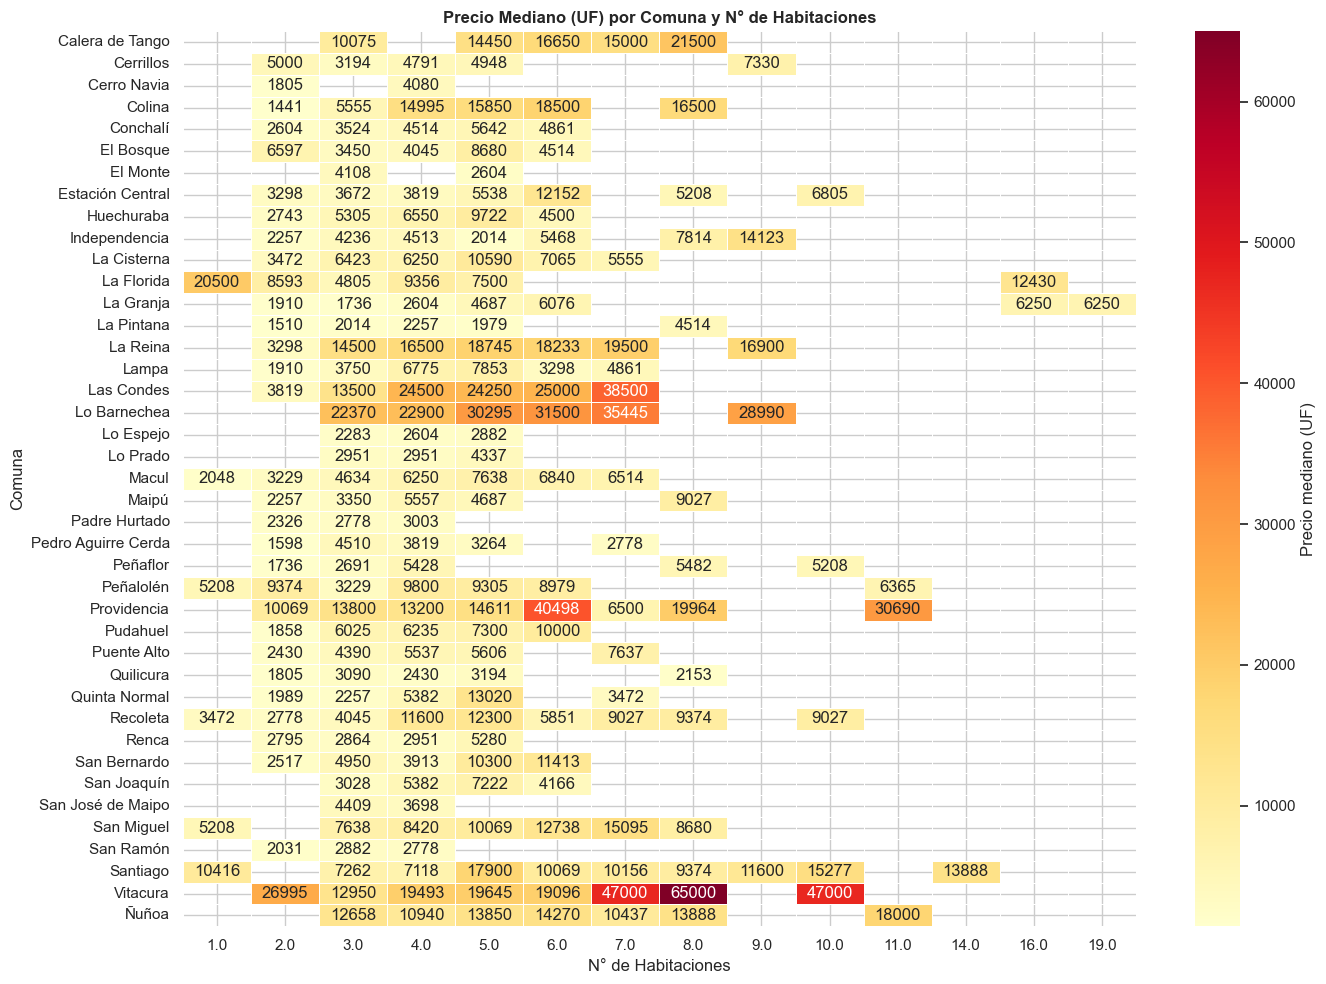

In [80]:
# Visualización del pivot con heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Precio mediano (UF)'})
plt.title('Precio Mediano (UF) por Comuna y N° de Habitaciones', fontweight='bold')
plt.xlabel('N° de Habitaciones')
plt.ylabel('Comuna')
plt.tight_layout()
plt.savefig('../outputs/06_pivot_comuna_habitaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumen del EDA

### Decisiones técnicas tomadas

| Decisión | Justificación técnica |
|---|---|
| **Variable objetivo**: `precio_sobre_mediana` (0/1) | Convierte regresión en clasificación binaria. Mediana más robusta que media ante outliers |
| **Eliminar** `Link`, `Tipo_Vivienda`, `Dirección`, `Quién_Vende`, `Corredor` | No son características de la propiedad, o tienen cardinalidad excesiva |
| **Eliminar** `Valor_CLP` | Derivado directo de `Valor_UF` → data leakage total |
| **Winsorización IQR** en `Valor_UF` | Preserva registros en lugar de eliminarlos; limita distorsión |
| **Imputación por mediana** para nulos numéricos | La mediana es robusta ante la distribución sesgada del dataset |
| **Conversión** `N_Estacionamientos` y `Superficie_Construida_M2` | Columnas object que deben ser numéricas para el modelo |

### Próximo paso
→ **Notebook 02_Pipelines.ipynb**: construcción del pipeline scikit-learn y validación final.
